In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:

# ==============================================================================
# 0. CONFIGURAZIONE E CARICAMENTO DATI (11 NODI TOTALI)
# ==============================================================================

# --- Setup del Percorso per Notebook Jupyter ---
DATA_PATH = Path('../data')
BASE_DIR = Path('..') 

START_YEAR = 2014
END_YEAR = 2024

# --- Definizione delle Colonne Richieste (per 11 Nodi) ---
REQUIRED_COLS_PERFORMANCE = [
    'w_ace', 'l_ace', 'w_df', 'l_df', 'w_svpt', 'l_svpt',
    'w_1stIn', 'l_1stIn', 'w_1stWon', 'l_1stWon',
    'w_2ndWon', 'l_2ndWon', 'w_bpSaved', 'l_bpSaved', 'w_bpFaced', 'l_bpFaced'
]
REQUIRED_COLS_INFO = [
    'winner_rank', 'loser_rank', 'surface', 'tourney_level', # Nodo Contesto
    'winner_age', 'loser_age',
    'winner_ht', 'loser_ht',
    'winner_hand', 'loser_hand'
]
REQUIRED_ALL = REQUIRED_COLS_PERFORMANCE + REQUIRED_COLS_INFO

INITIAL_COLS = ['tourney_id'] + REQUIRED_ALL

# --- 0.1 Caricamento e Unione Dati (Logica Robusta) ---
matches_list = []
skipped_files = []

print(f"--- 0.1 Inizio Caricamento Dati ({START_YEAR}-{END_YEAR}) ---")
all_match_files = sorted(list(DATA_PATH.glob('atp_matches_*.csv')))

if not all_match_files:
    raise FileNotFoundError(f"Nessun file 'atp_matches_*.csv' trovato in {DATA_PATH}.")

for match_file in all_match_files:
    try:
        df = pd.read_csv(match_file, low_memory=False)
        missing_cols = [col for col in INITIAL_COLS if col not in df.columns.tolist()]
        
        if not missing_cols:
            matches_list.append(df[INITIAL_COLS])
        else:
            critical_missing = [col for col in INITIAL_COLS if col not in df.columns.tolist() and col not in REQUIRED_COLS_PERFORMANCE]
            if critical_missing:
                skipped_files.append(f"{match_file.name} (SALTO: Mancano colonne CRITICHE: {', '.join(critical_missing)})")
            else:
                for col in missing_cols:
                    df[col] = np.nan
                matches_list.append(df[INITIAL_COLS])
                skipped_files.append(f"{match_file.name} (RECUPERO: Aggiunte e riempite con NaN le colonne: {', '.join(missing_cols)})")

    except Exception as e:
        skipped_files.append(f"{match_file.name} (ERRORE di lettura: {e})")

if not matches_list:
    raise FileNotFoundError("Nessun match valido è stato caricato.")

full_df = pd.concat(matches_list, ignore_index=True)

# 0.2 Pulizia Finale
initial_rows = len(full_df)
full_df.dropna(subset=REQUIRED_ALL, inplace=True) 
dropped_rows = initial_rows - len(full_df)

print(f"\nSUCCESSO: Dataset Integrato e Pulito con {len(full_df)} partite complete.")
print(f"NOTA: Rimosse {dropped_rows} righe con statistiche mancanti (dopo l'unione).")


--- 0.1 Inizio Caricamento Dati (2014-2024) ---

SUCCESSO: Dataset Integrato e Pulito con 28728 partite complete.
NOTA: Rimosse 1845 righe con statistiche mancanti (dopo l'unione).


In [3]:
# ==============================================================================
# 1. FEATURE ENGINEERING (LOGICA SEMPLICE E PASSAGGI ESPLICITI)
# ==============================================================================

final_df = pd.DataFrame()

# 1. Determinazione del Favorito
full_df['is_winner_favorite'] = full_df['winner_rank'] < full_df['loser_rank']

# --- A. Nodo Target, Contesto e Status Base ---
final_df['Risultato_Favorevole'] = full_df['is_winner_favorite'].map({True: 'Vittoria', False: 'Sconfitta'})
final_df['Superficie'] = full_df['surface'].astype(str)
final_df['Tourney_Level'] = full_df['tourney_level'].astype(str)

# Calcolo Diff_Rank (Passaggio Esplicito)
final_df['Diff_Rank'] = full_df.apply(
    lambda row: row['loser_rank'] - row['winner_rank'] if row['is_winner_favorite'] 
    else row['winner_rank'] - row['loser_rank'], 
    axis=1
)

# --- B. Nodi Performance (Differenze Semplici) ---

# Calcolo Diff_Ace (Passaggio Esplicito)
final_df['Diff_Ace'] = full_df.apply(
    lambda row: row['w_ace'] - row['l_ace'] if row['is_winner_favorite'] 
    else row['l_ace'] - row['w_ace'], 
    axis=1
)

# Calcolo Diff_DF (Passaggio Esplicito)
final_df['Diff_DF'] = full_df.apply(
    lambda row: row['w_df'] - row['l_df'] if row['is_winner_favorite'] 
    else row['l_df'] - row['w_df'], 
    axis=1
)

# Calcolo Diff_ServiceWinPerc (Passaggio Esplicito)
full_df['w_service_win_perc'] = (full_df['w_1stWon'] + full_df['w_2ndWon']) / full_df['w_svpt']
full_df['l_service_win_perc'] = (full_df['l_1stWon'] + full_df['l_2ndWon']) / full_df['l_svpt']
final_df['Diff_ServiceWinPerc'] = full_df.apply(
    lambda row: row['w_service_win_perc'] - row['l_service_win_perc'] if row['is_winner_favorite'] 
    else row['l_service_win_perc'] - row['w_service_win_perc'], 
    axis=1
)
final_df['Diff_ServiceWinPerc'] = final_df['Diff_ServiceWinPerc'].replace([np.inf, -np.inf], np.nan)


# --- C. Nodi Caratteristiche del Giocatore (Del Favorito) ---

# Fav_Age (Passaggio Esplicito)
final_df['Fav_Age'] = full_df.apply(
    lambda row: row['winner_age'] if row['is_winner_favorite'] 
    else row['loser_age'], 
    axis=1
)

# Fav_Ht (Passaggio Esplicito)
final_df['Fav_Ht'] = full_df.apply(
    lambda row: row['winner_ht'] if row['is_winner_favorite'] 
    else row['loser_ht'], 
    axis=1
)

# Fav_Hand (Passaggio Esplicito)
final_df['Fav_Hand'] = full_df.apply(
    lambda row: row['winner_hand'] if row['is_winner_favorite'] 
    else row['loser_hand'], 
    axis=1
).astype('category')

# Hand Matchup (Passaggio Esplicito)
def get_hand_matchup_simple(row):
    # --- CORREZIONE ---
    # Calcoliamo hand_fav e hand_sfav usando solo 'row' (che proviene da full_df)
    
    if row['is_winner_favorite']:
        hand_fav = row['winner_hand']
        hand_sfav = row['loser_hand']
    else:
        hand_fav = row['loser_hand']
        hand_sfav = row['winner_hand']
    # --- FINE CORREZIONE ---
    
    if hand_fav == hand_sfav:
        return 'StessaMano'
    elif hand_fav in ['R', 'L'] and hand_sfav in ['R', 'L']:
        return 'Opposta'
    else:
        return 'Sconosciuta' 

final_df['Hand_Matchup'] = full_df.apply(get_hand_matchup_simple, axis=1).astype('category')


# Pulizia finale post-calcolo
final_df.dropna(inplace=True) 

# DataFrame Numerico Finale (10 Feature + Target)
data_numerica_pronta = final_df[[
    'Superficie', 'Tourney_Level', 'Diff_Rank', 'Fav_Age', 'Fav_Ht', 'Fav_Hand', 
    'Hand_Matchup', 'Diff_Ace', 'Diff_DF', 'Diff_ServiceWinPerc',
    'Risultato_Favorevole'
]].copy()

print("\n--- 1. FASE 1 COMPLETATA: DataFrame Numerico Semplificato Pronto ---")


--- 1. FASE 1 COMPLETATA: DataFrame Numerico Semplificato Pronto ---



--- 2. FASE 2 INIZIO: Analisi Esplorativa dei Dati (EDA) Completa ---

1. Analisi Contesto (Superficie & Livello):


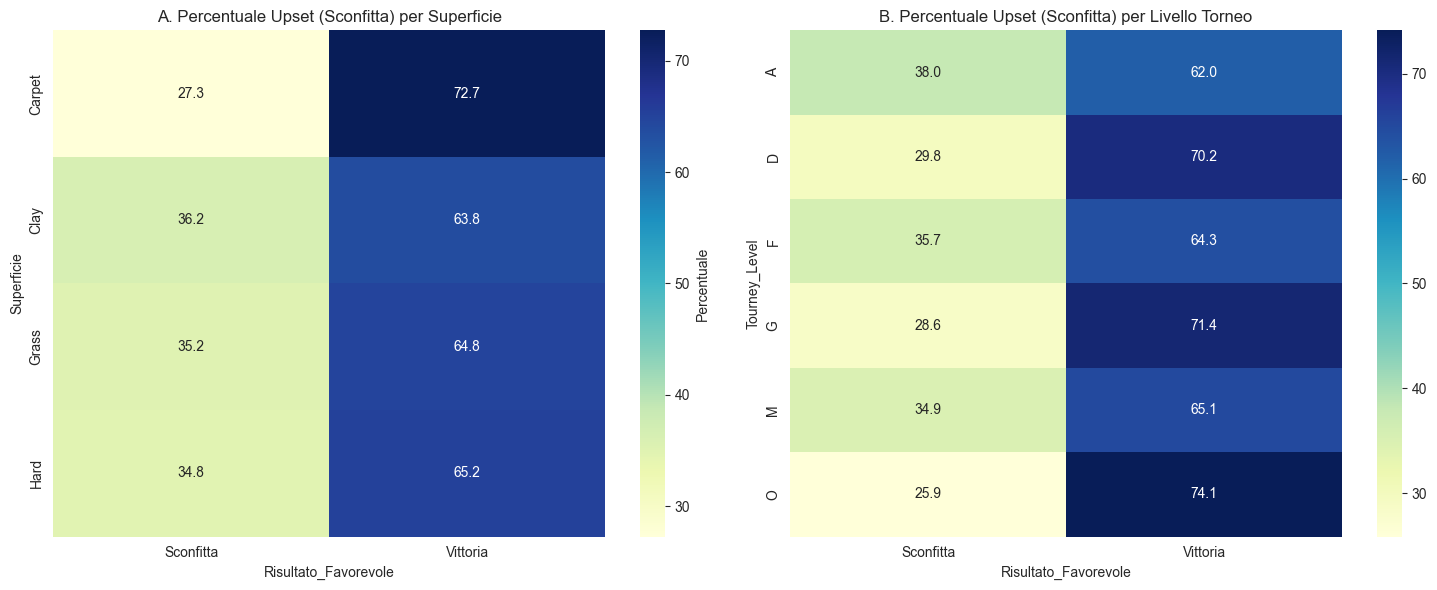


2. Analisi Distribuzioni e Correlazioni:


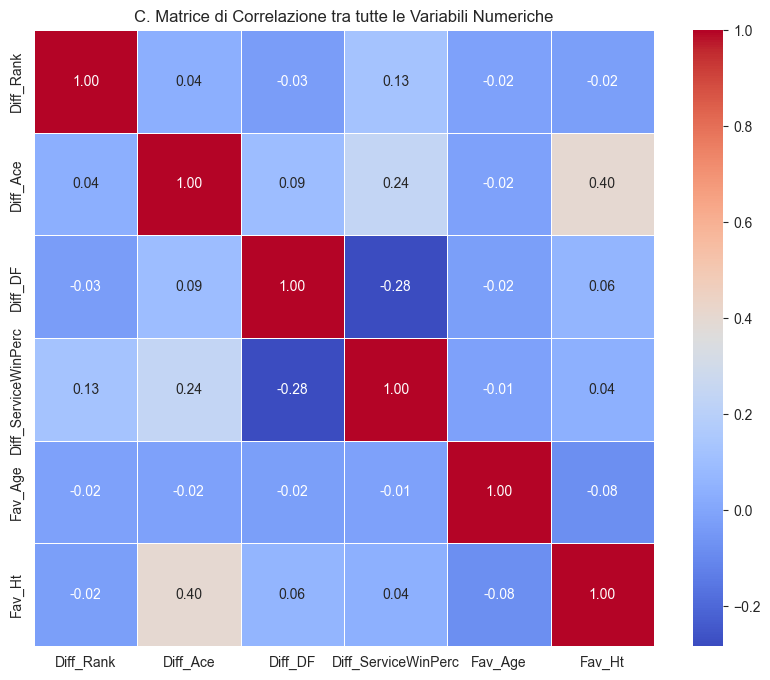

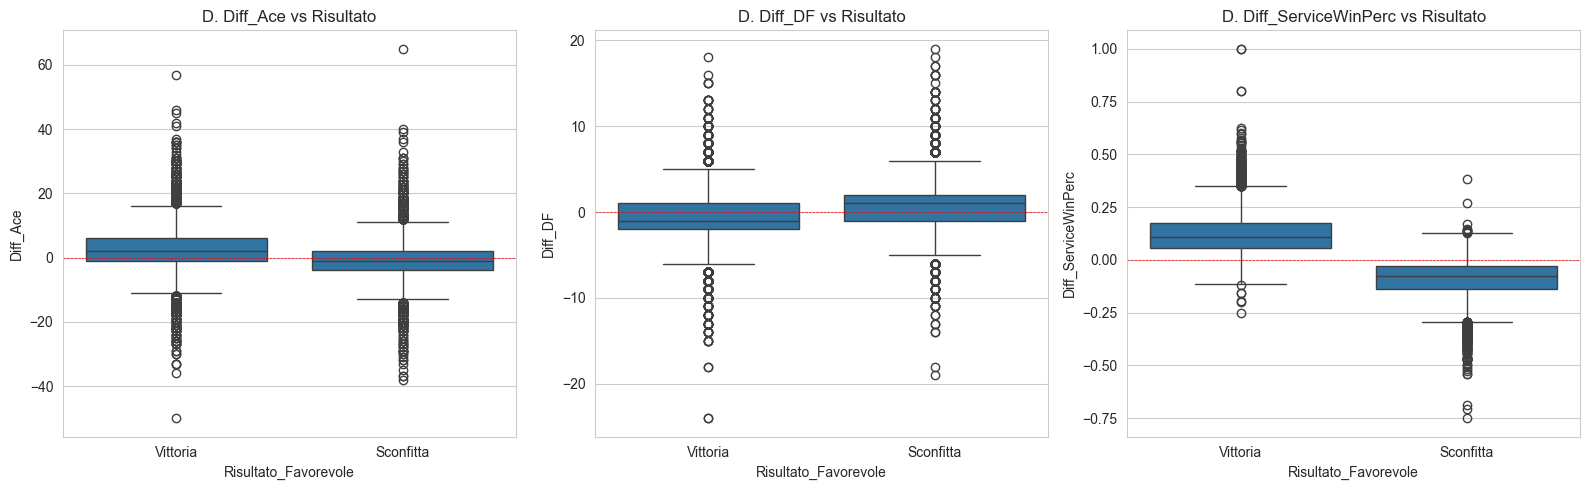


3. Analisi Multivariata: Impatto delle Performance per Superficie (Chiave del Progetto):


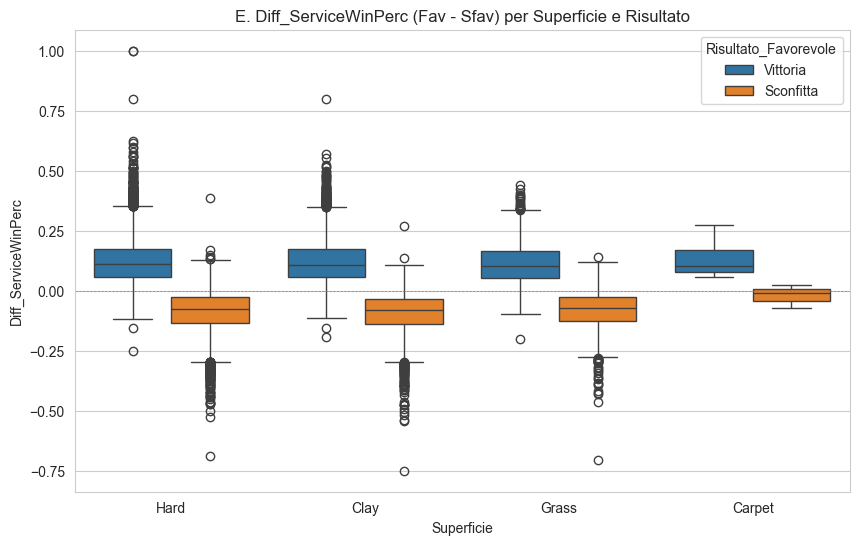

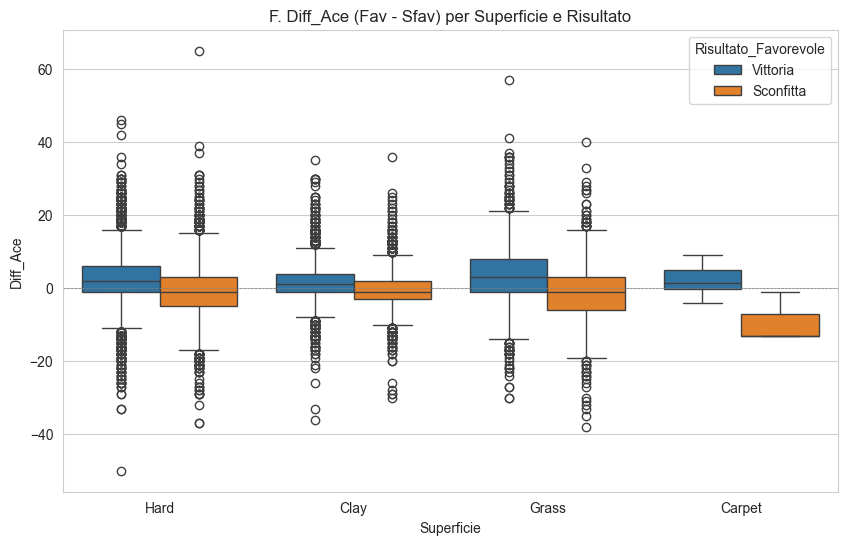


4. Analisi delle Caratteristiche del Giocatore (Nuovi Nodi):


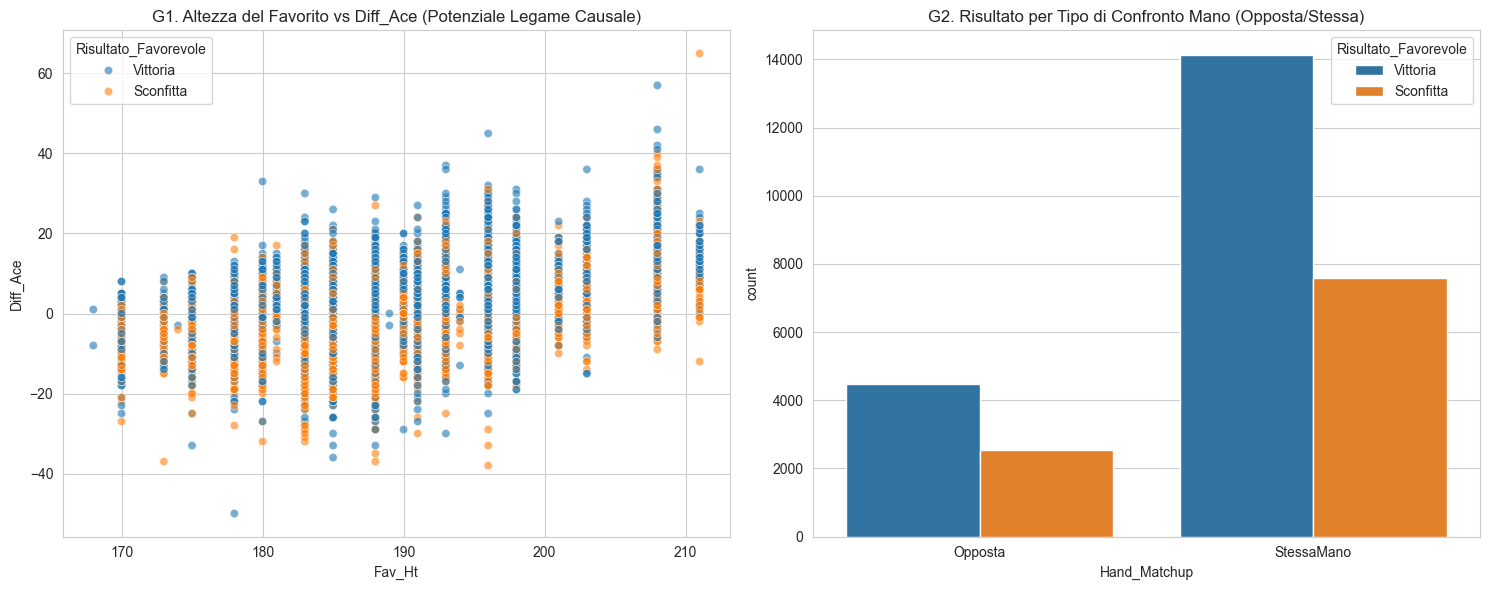


--- 2. FASE 2 COMPLETATA: Analisi Visiva Eseguita ---


In [4]:
# ==============================================================================
# 2. EDA (ANALISI ESPLORATIVA DEI DATI) - CORRETTA
# ==============================================================================

print("\n--- 2. FASE 2 INIZIO: Analisi Esplorativa dei Dati (EDA) Completa ---")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

# 2.1 ANALISI CONTESTUALE
print("\n1. Analisi Contesto (Superficie & Livello):")
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
contingency_surf = pd.crosstab(data_numerica_pronta['Superficie'], data_numerica_pronta['Risultato_Favorevole'], normalize='index') * 100
sns.heatmap(contingency_surf, annot=True, cmap="YlGnBu", fmt=".1f", cbar_kws={'label': 'Percentuale'})
plt.title('A. Percentuale Upset (Sconfitta) per Superficie')

plt.subplot(1, 2, 2)
# --- CORREZIONE QUI ---
# Abbiamo usato 'Tourney_Level' (maiuscolo) invece di 'tourney_level' (minuscolo)
contingency_level = pd.crosstab(data_numerica_pronta['Tourney_Level'], data_numerica_pronta['Risultato_Favorevole'], normalize='index') * 100
# (Ho rimosso anche il 'fmt=".1f"' duplicato che avevi)
sns.heatmap(contingency_level, annot=True, cmap="YlGnBu", fmt=".1f") 
plt.title('B. Percentuale Upset (Sconfitta) per Livello Torneo')
plt.tight_layout()
plt.show()

# 2.2 ANALISI DELLE DIFFERENZE E CORRELAZIONE
print("\n2. Analisi Distribuzioni e Correlazioni:")
COLS_NUMERIC = ['Diff_Rank', 'Diff_Ace', 'Diff_DF', 'Diff_ServiceWinPerc', 'Fav_Age', 'Fav_Ht']
plt.figure(figsize=(10, 8))
corr_matrix = data_numerica_pronta[COLS_NUMERIC].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('C. Matrice di Correlazione tra tutte le Variabili Numeriche')
plt.show() # 

plt.figure(figsize=(16, 5))
for i, col in enumerate(['Diff_Ace', 'Diff_DF', 'Diff_ServiceWinPerc']): 
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x='Risultato_Favorevole', y=col, data=data_numerica_pronta)
    plt.axhline(0, color='red', linestyle='--', linewidth=0.5)
    plt.title(f'D. {col} vs Risultato')
plt.tight_layout()
plt.show()

# 2.3 ANALISI MULTIVARIATA (Performance vs Risultato vs Superficie)
print("\n3. Analisi Multivariata: Impatto delle Performance per Superficie (Chiave del Progetto):")

# Diff_ServiceWinPerc
plt.figure(figsize=(10, 6))
sns.boxplot(x='Superficie', y='Diff_ServiceWinPerc', hue='Risultato_Favorevole', data=data_numerica_pronta)
plt.title('E. Diff_ServiceWinPerc (Fav - Sfav) per Superficie e Risultato')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.5)
plt.show()

# Diff_Ace
plt.figure(figsize=(10, 6))
sns.boxplot(x='Superficie', y='Diff_Ace', hue='Risultato_Favorevole', data=data_numerica_pronta)
plt.title('F. Diff_Ace (Fav - Sfav) per Superficie e Risultato')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.5)
plt.show()

# 2.4 ANALISI DELLE NUOVE FEATURE (Età, Altezza, Mano)
print("\n4. Analisi delle Caratteristiche del Giocatore (Nuovi Nodi):")
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Fav_Ht', y='Diff_Ace', data=data_numerica_pronta, hue='Risultato_Favorevole', alpha=0.6)
plt.title('G1. Altezza del Favorito vs Diff_Ace (Potenziale Legame Causale)')

plt.subplot(1, 2, 2)
sns.countplot(x='Hand_Matchup', hue='Risultato_Favorevole', data=data_numerica_pronta)
plt.title('G2. Risultato per Tipo di Confronto Mano (Opposta/Stessa)')
plt.tight_layout()
plt.show()

print("\n--- 2. FASE 2 COMPLETATA: Analisi Visiva Eseguita ---")

In [5]:

# ==============================================================================
# 3. DISCRETIZZAZIONE (CREAZIONE DEGLI 11 STATI CATEGORICI)
# ==============================================================================

print("\n--- 3. FASE 3 INIZIO: Discretizzazione ---")

data_discretizzata = data_numerica_pronta.copy()

# --- 3.1 Discretizzazione dei Valori Numerici ---
# Cat_Rank (Binning Fisso)
bins_rank = [-float('inf'), 15, 50, float('inf')]
labels_rank = ['Equilibrato', 'FavoritoMedio', 'FavoritoNetto']
data_discretizzata['Cat_Rank'] = pd.cut(data_discretizzata['Diff_Rank'], bins=bins_rank, labels=labels_rank, right=True, include_lowest=True)

# Cat_Performance, Età, Altezza (Quantile Binning - q=3)
COLS_TO_BIN_QUANTILE = ['Diff_Ace', 'Diff_DF', 'Diff_ServiceWinPerc', 'Fav_Age', 'Fav_Ht']
for col in COLS_TO_BIN_QUANTILE:
    new_col_name = col.replace('Diff_', 'Cat_').replace('Fav_', 'Cat_')
    data_discretizzata[new_col_name] = pd.qcut(
        data_discretizzata[col],
        q=3,
        labels=['Inferiore', 'Medio', 'Superiore'],
        duplicates='drop'
    )
print("  - Discretizzazione di Rank, Performance, Età e Altezza completata.")


# --- 3.2 Finalizzazione e Selezione dei Nodi ---
data_finale_pgmpy = data_discretizzata[[
    'Superficie', 'Tourney_Level', 'Cat_Rank', 'Cat_Age', 'Cat_Ht', 
    'Fav_Hand', 'Hand_Matchup', 'Cat_Ace', 'Cat_DF', 'Cat_ServiceWinPerc', 
    'Risultato_Favorevole' 
]].copy()

# Conversione di tutti i nodi a tipo 'category'
for col in data_finale_pgmpy.columns:
    data_finale_pgmpy[col] = data_finale_pgmpy[col].astype('category')

print(f"\nDataFrame finale pronto con {len(data_finale_pgmpy.columns)} nodi.")
print("\n--- 3. FASE 3 COMPLETATA: DataFrame categorico pronto ---")



--- 3. FASE 3 INIZIO: Discretizzazione ---
  - Discretizzazione di Rank, Performance, Età e Altezza completata.

DataFrame finale pronto con 11 nodi.

--- 3. FASE 3 COMPLETATA: DataFrame categorico pronto ---


In [6]:

# ==============================================================================
# 4. SALVATAGGIO CSV PER NOTEBOOK PGMpy
# ==============================================================================

OUTPUT_PATH = BASE_DIR / 'processed_data'
OUTPUT_PATH.mkdir(exist_ok=True) 

OUTPUT_FILE = OUTPUT_PATH / 'atp_matches_discretized.csv'

# Salva il file senza l'indice (index=False)
data_finale_pgmpy.to_csv(OUTPUT_FILE, index=False)

print("\n--- 4. SALVATAGGIO COMPLETATO ---")
print(f"Dati finali salvati in: {OUTPUT_FILE.resolve()}")
print("Procedi ora al Notebook 'pgm_model.ipynb' (FASE 4).")


--- 4. SALVATAGGIO COMPLETATO ---
Dati finali salvati in: C:\Users\simon\Desktop\Fundamentals_Of_AI_MOD3\Progetto\processed_data\atp_matches_discretized.csv
Procedi ora al Notebook 'pgm_model.ipynb' (FASE 4).
